## ECFP и отпечатки Моргана

In [4]:
from rdkit.Chem import Draw
# Для отрисовки структур молекул (например, в Jupyter Notebook)

from rdkit import DataStructs
# Работа с битовыми векторами и вычисление схожести между фингерпринтами

from rdkit.Chem import AllChem
# Содержит функции для генерации фингерпринтов, оптимизации молекул и т.д.
# Например: Morgan-фингерпринты

from rdkit import Chem
# Основной модуль RDKit для работы с молекулами:
# преобразование SMILES → Mol, работа с атомами/связями и т.д.

from rdkit.Chem.MolStandardize import rdMolStandardize
# Инструменты для стандартизации молекул (например, удаление металлов, нормализация структур)

from rdkit.Chem import MACCSkeys
# Генерация MACCS-фингерпринтов — фиксированный набор 166 бит

from rdkit.Chem import PandasTools
# Удобные функции для интеграции RDKit с pandas DataFrame:
# добавление столбца с молекулами, отрисовка таблиц и т.д.

from rdkit.Chem import Descriptors
# Вычисление физико-химических дескрипторов молекул:
# LogP, молекулярная масса, количество H-доноров и акцепторов и т.д.

from rdkit.ML.Descriptors import MoleculeDescriptors
# Позволяет рассчитать сразу все доступные дескрипторы

from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG
# Поддержка отображения молекул как SVG-изображений в Jupyter Notebook

IPythonConsole.ipython_useSVG = True
# Включаем отображение молекул в векторном формате (красивее и чётче)

import pandas as pd
# Работа с табличными данными (DataFrame)

import numpy as np
# Работа с числовыми массивами и матрицами

from difflib import SequenceMatcher
# Для сравнения строк (может пригодиться при анализе похожих SMILES или названий молекул)

from rdkit import RDLogger
# Отключаем все логи/предупреждения RDKit
RDLogger.DisableLog('rdApp.*')

## Преобразование в Mol и отрисовка молекул

In [5]:
smiles = 'Cn1cnc2c1c(=O)n(C)c(=O)n2C'

Вызов mol-файла позволяет сразу отрисовать молекулы

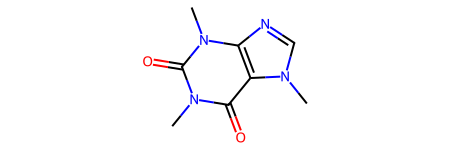

In [6]:
mol = Chem.MolFromSmiles(smiles)
mol

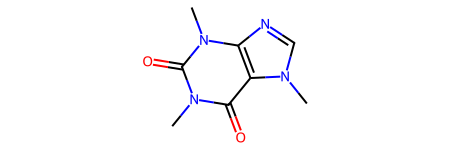

In [7]:
# Применяем функцию Cleanup к молекуле — это первый шаг в стандартизации
# Метод убирает нежелательные части (например, металлы, заряды), нормализует структуру
clean_mol = rdMolStandardize.Cleanup(mol)

# Выводим очищенную молекулу (в Jupyter Notebook она отобразится как структурная формула)
clean_mol

In [8]:
sm = Chem.MolToSmiles(mol)
sm

'Cn1c(=O)c2c(ncn2C)n(C)c1=O'

Заметим, что полученный нами SMILES отличается от введенного - операция перевода SMILES в mol и обратно по сути осуществляет приведение SMILES в "канонический" (задаваемый детерминированными алгоритмами RDKit) вид

Посчитаем расстояние между исходным и стандартизованным SMILES

In [9]:
# Создаём объект SequenceMatcher для сравнения двух строк SMILES
# None — это параметр, который мы передаём, потому что не используем функцию-токенизатор
s = SequenceMatcher(None, smiles, sm)

# Вычисляем коэффициент похожести между двумя SMILES (значение от 0 до 1)
s.ratio()

0.5769230769230769

Данное число демонстрирует, что строки не слишком похожи

In [10]:
#повторим операции для другой молекулы
smiles2 = 'Cn1ccc2n(C)c(=O)n(C)c(=O)c12'
mol2 = Chem.MolFromSmiles(smiles2)
sm2 = Chem.MolToSmiles(mol2)
sm2

'Cn1c(=O)c2c(ccn2C)n(C)c1=O'

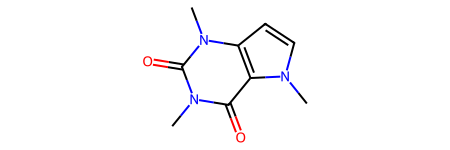

In [11]:
#отрисуем данную молекулу
mol2

In [12]:
s = SequenceMatcher(None, sm, sm2)
s.ratio()

0.9615384615384616

Иными словами, SMILES различных молекул отличается существенно меньше, чем SMILES одной и той же молекулы в каноническом и неканоническом виде. Из-за подобного сравнение молекул при помощи SMILES является крайне нежелательным

## MACCS-ключи

In [13]:
# Генерируем MACCS-фингерпринт для молекулы — это бинарный вектор длиной 166 бит
# Каждый бит соответствует наличию (1) или отсутствию (0) определённого structural key
maccs_fp = MACCSkeys.GenMACCSKeys(mol)

# Преобразуем фингерпринт в массив NumPy
maccs_array = np.array(maccs_fp)

# Находим индексы тех битов, которые равны 1 (то есть признаки, присутствующие в молекуле)
active_bits = maccs_array.nonzero()

# active_bits — это кортеж из одного массива с индексами активных битов
# Чтобы получить просто список индексов, можно взять первый элемент:
active_bits_list = active_bits[0]

In [14]:
active_bits_list

array([ 37,  38,  65,  75,  77,  79,  80,  83,  85,  89,  92,  93,  95,
        96,  97,  98, 101, 105, 106, 110, 113, 117, 120, 121, 122, 125,
       127, 136, 137, 141, 142, 143, 144, 148, 149, 150, 154, 156, 158,
       159, 160, 161, 162, 163, 164, 165])

Если хочется посмотреть, что означают конкретные биты MACCS, можно найти документацию по MACCS keys, например здесь:
https://github.com/rdkit/rdkit/blob/master/rdkit/Chem/MACCSkeys.py

Структурные ключи MACCS тесно связаны с иным строчным представлением молекулы - SMARTS. SMARTS — это расширение SMILES, которое позволяет описывать не конкретную молекулу, а паттерн (шаблон), что очень пригождается для поиска определённых фрагментов в молекулах.

In [24]:
smarts = Chem.MolToSmarts(mol)
smarts

'[#6]-[#7]1:[#6]:[#7]:[#6]2:[#6]:1:[#6](=[#8]):[#7](-[#6]):[#6](=[#8]):[#7]:2-[#6]'

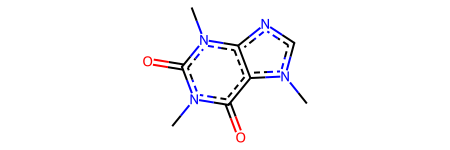

In [25]:
Chem.MolFromSmarts(smarts)

## Отпечаток Моргана (ECFP)

Сам отпечаток Моргана - это битный вектор (состоит из "1" и "0") размера n_bits, получаемый при помощи хэширования extended-connectivity fingerprints (ECFP). Параметр radius определяет радиус обхода ECFP.

Данные параметры обеспечивают гибкость отпечатка, позволяя подобрать уровень детальности описания молекулы и размер представления исходя из размеров задачи

In [26]:
# Создаем пустой словарь `bi` (bitInfo), в который будут сохранены данные:
# какие атомы и их окружение отвечают за каждый активный бит фингерпринта
bi = {}

# Генерируем Morgan-фингерпринт как BitVect для молекулы `mol`
# radius=2 — учитываем структуру вокруг каждого атома в радиусе 2 связей
# bitInfo=bi — записываем информацию о происхождении каждого бита в словарь bi
# nBits=1024 — длина выходного вектора (сколько всего возможных битов может быть использовано)
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, bitInfo=bi, nBits=1024)

# Преобразуем полученный фингерпринт в NumPy-массив и выводим его
# Это бинарный массив из 0 и 1: 1 — признак присутствует, 0 — отсутствует
print(np.array(fp))

[1 0 0 ... 0 0 0]


In [27]:
print(np.nonzero(np.array(fp)))

(array([  0,  33, 121, 179, 234, 283, 314, 330, 356, 378, 385, 400, 416,
       428, 463, 493, 504, 564, 650, 672, 771, 849, 932, 935]),)


Отрисуем обнаруженные в молекуле подструктуры с использавнием введенного раньше словаря bi.

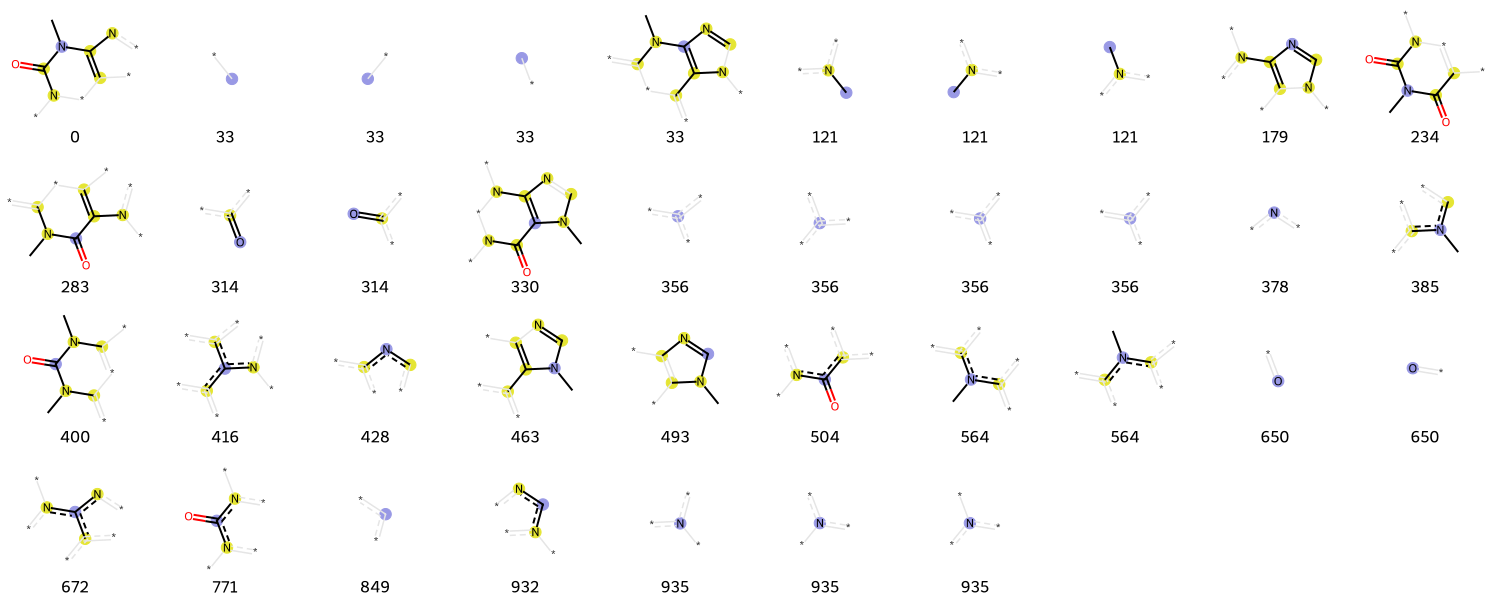

In [28]:
list_bits = []
legends = []
for x in fp.GetOnBits():
    for i in range(len(bi[x])):
        list_bits.append((mol,x,bi,i))
        legends.append(str(x))
Draw.DrawMorganBits(list_bits, molsPerRow=10,legends=legends)

Посчитаем отпечаток для второй молекулы. Замечу, что для работы кода bitInfo совершенно необязательно сохранять

In [29]:
fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, radius=2, nBits=1024)

Теперь мы можем вычислить коэффициент Танимото между отпечатками молекул

In [30]:
DataStructs.TanimotoSimilarity(fp, fp2)

0.45454545454545453

Как правило, "похожими" считаются структуры с коэффициентом Танимото больше 0.5 (хотя это существенно зависит от радиуса и количества бит в отпечатках Моргана - для меньшего размера отпечатка и меньшего радиуса будет характерно более высокое сходство молекул)

## Дескрипторы RDKit

In [31]:
def RDkit_descriptors(smiles):
    # Преобразуем каждую строку SMILES в объект молекулы (mol) с помощью RDKit
    mols = [Chem.MolFromSmiles(i) for i in smiles]

    # Создаём объект для вычисления всех стандартных дескрипторов из Descriptors._descList
    # calc — это "калькулятор", который умеет считать сразу много дескрипторов
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])

    # Получаем список имён всех используемых дескрипторов, чтобы знать, какой индекс к какому дескриптору относится
    desc_names = calc.GetDescriptorNames()

    # Список для хранения списков дескрипторов для каждой молекулы
    Mol_descriptors = []

    # Для каждой молекулы вычисляем все дескрипторы
    for mol in mols:
        # Добавляем атомы водорода к молекуле — некоторые дескрипторы требуют их наличия
        mol = Chem.AddHs(mol)

        # Вычисляем дескрипторы для текущей молекулы
        descriptors = calc.CalcDescriptors(mol)

        # Добавляем кортеж с результатами в общий список
        Mol_descriptors.append(descriptors)

    # Возвращаем два значения:
    # - список списков/кортежей с численными значениями дескрипторов
    # - список имён дескрипторов
    return Mol_descriptors, desc_names

In [32]:
# вызываем функцию для ранее созданных smiles
Mol_descriptors,desc_names = RDkit_descriptors([sm, sm2])

In [33]:
#создадим датафрейм с полученными значениями и названиями колонок для удобства чтения
df_with_descriptors = pd.DataFrame(Mol_descriptors,columns=desc_names)

In [34]:
df_with_descriptors

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.367750,12.367750,0.086921,-3.359734,0.538463,24.285714,194.194,184.114,194.080376,74,...,0,0,0,0,0,0,0,0,0,0
1,12.476639,12.476639,0.066389,-3.399227,0.570024,25.285714,193.206,182.118,193.085127,74,...,0,0,0,0,0,0,0,0,0,0


Мы также можем вызвать и рассчитать конкретные необходимые нам дескрипторы по их названиям

In [35]:
calc = MoleculeDescriptors.MolecularDescriptorCalculator(['RingCount', 'MolWt'])
descriptors = calc.CalcDescriptors(Chem.MolFromSmiles(sm))
descriptors

(2, 194.194)

# Использование RDKit с Pandas DataFrame

In [38]:
df = pd.read_csv('chembl_drugs.csv', sep='\t')
df

,PARENT_MOLREGNO,CHEMBL_ID,SYNONYMS,DEVELOPMENT_PHASE,RESEARCH_CODES,APPLICANTS,USAN_STEM,USAN_STEM_DEFINITION,USAN_STEM_SUBSTEM,USAN_YEAR,...,PRODRUG,ORAL,PARENTERAL,TOPICAL,BLACK_BOX,AVAILABILITY_TYPE,WITHDRAWN_YEAR,WITHDRAWN_COUNTRY,WITHDRAWN_REASON,CANONICAL_SMILES
0,675015,CHEMBL1201064,"Fluorometholone Acetate (FDA, USAN)",4,U-17323,Alcon Laboratories Inc,-olone,steroids (not prednisolone derivatives),-olone,1984.0,...,Y,N,N,Y,N,Prescription-only,NaN,NaN,NaN,C[C@H]1C[C@H]2[C@@H]3CC[C@](OC(=O)C)(C(=O)C)[C...
1,112655,CHEMBL1009,"Levodopa (BAN, FDA, INN, JAN, USAN, USP)",4,NaN,Shire Development Inc; Orion Pharma; Merck Sha...,-dopa,dopamine receptor agonists,-dopa,1969.0,...,N,Y,N,N,N,Prescription-only,NaN,NaN,NaN,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O
2,993371,CHEMBL1569487,"Lornoxicam (BAN, INN, USAN)",3,Ro-139297,"Cl Pharma Ag, Austria",-icam,anti-inflammatory agents (isoxicam type),-icam,1993.0,...,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CN1C(=C(O)c2sc(Cl)cc2S1(=O)=O)C(=O)Nc3ccccn3
3,435293,CHEMBL270190,"Alvimopan (BAN, FDA, INN, USAN)",4,ADL 8-2698,Cubist Pharmaceuticals Inc,NaN,NaN,NaN,2002.0,...,N,Y,N,N,Y,Prescription-only,NaN,NaN,NaN,C[C@H]1CN(C[C@H](Cc2ccccc2)C(=O)NCC(=O)O)CC[C@...
4,246,CHEMBL9,"Norfloxacin (BAN, FDA, INN, JAN, USAN, USP)",4,MK-366,Merck Research Laboratories Div Merck Co Inc,-oxacin,antibacterials (quinolone derivatives),-oxacin,1984.0,...,N,Y,N,Y,Y,Prescription-only,NaN,NaN,NaN,CCN1C=C(C(=O)O)C(=O)c2cc(F)c(cc12)N3CCNCC3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11437,675456,CHEMBL1201438,"Aldesleukin (BAN, FDA, INN, USAN)",4,NaN,Seragen Inc; Chiron Corp; Chiron,-kin,interleukins: interleukin-2 analogues and deri...,-kin (-leukin),1990.0,...,N,N,Y,N,Y,Prescription-only,NaN,NaN,NaN,NaN
11438,675480,CHEMBL1201571,"Alefacept (BAN, FDA, INN, USAN)",4,BG-9273; BG-9712; Lfa3Tip,Biogen Inc,-cept,"receptor molecules, native or modified: lympho...",-cept (-facept),2000.0,...,N,N,Y,N,N,Prescription-only,NaN,NaN,NaN,NaN
11439,675534,CHEMBL1201631,"Insulin (BAN, JAN, USP); Insulin Human (BAN, I...",4,NaN,Pfizer Inc.; Novo Nordisk Inc; Eli Lilly And C...,NaN,NaN,NaN,1983.0,...,N,N,Y,Y,N,Over-The-Counter,NaN,NaN,NaN,NaN
11440,675578,CHEMBL1201576,"Rituximab (BAN, FDA, INN, USAN)",4,IDEC-102; IDEC-C2B8; R-105 IDEC-102; RG-105,Idec Pharmaceuticals Corp; Genentech Inc,-mab,monoclonal antibodies,-mab,1997.0,...,N,N,Y,N,Y,Prescription-only,NaN,NaN,NaN,NaN


Оставим в базе данных только уже внедренные (4 стадия разработки) и перорально активные (выполняющие правило Липински ("правило пяти")) лекарственные средства

In [ ]:
# Фильтруем строки DataFrame df по следующим условиям:

# 1. 'CANONICAL_SMILES' не должен быть пустым (notnull)
#    — у молекулы должно быть корректное SMILES-представление

# 2. 'USAN_STEM' также не должен быть пустым (notnull) - pharmacological class or chemical structure
#    — наличие информации о USAN-стволе может быть важной для классификации

# 3. 'RULE_OF_FIVE' должен быть равен 'Y'
#    — это означает, что молекула удовлетворяет правилу Липинского (липофильность, масса и т.д.)

# 4. 'DEVELOPMENT_PHASE' должен быть равен 4
#    — то есть молекула находится на финальной стадии разработки (рынок / одобрена)

df = df[df['CANONICAL_SMILES'].notnull() &
        df['USAN_STEM'].notnull() &
        (df['RULE_OF_FIVE'] == 'Y') &
        (df['DEVELOPMENT_PHASE'] == 4)]

# Выводим количество строк, которые соответствуют всем этим условиям
len(df)

700

Добавим в датасет колонку с mol-файлами (напомню, это необходимо для получения моргановских отпечатков)

In [40]:
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='CANONICAL_SMILES', molCol='Molecule')

/opt/miniconda3/envs/first/lib/python3.12/site-packages/rdkit/Chem/PandasTools.py:381: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame[molCol] = frame[smilesCol].map(Chem.MolFromSmiles)


Отфильтруем невалидные молекулы

In [41]:
# Удаляем из DataFrame все строки, где значение в столбце 'Molecule' равно NaN (пустое / отсутствующее)
df = df[~df['Molecule'].isnull()]

In [55]:
df.groupby('USAN_STEM').size().sort_values()

USAN_STEM
-metacin          1
-pamine           1
-oxin             1
-oxanide          1
-nil; -prost-     1
                 ..
-caine           15
-oxacin          17
-cillin          17
-olol            18
sulfa-           18
Length: 213, dtype: int64

In [42]:
# Группируем строки по значениям в столбце 'USAN_STEM' и считаем, сколько раз встречается каждый ствол
# groupby('USAN_STEM') — объединяем все молекулы с одинаковым USAN-стволом
# .size() — считаем количество молекул в каждой группе
# .sort_values() — сортируем результат по возрастанию (от самых редких к самым частым стволам)
# [-10:] — выбираем последние 10 записей, то есть **10 самых часто встречающихся стволов**

common_stems = df.groupby('USAN_STEM').size().sort_values()[-10:]

# Выводим результат
common_stems

USAN_STEM
-tinib     12
-olone     12
-pin(e)    12
-ium       14
-vir       15
-caine     15
-oxacin    17
-cillin    17
-olol      18
sulfa-     18
dtype: int64

In [47]:
# Создаём новый DataFrame new_df, в который включаем только те строки,
# где значение 'USAN_STEM' встречается среди 10 самых распространённых (common_stems)
# Также выбираем только три нужных столбца: 'Molecule', 'USAN_STEM', 'USAN_STEM_DEFINITION'
new_df = df[df['USAN_STEM'].isin(common_stems.index)][['Molecule', 'USAN_STEM', 'USAN_STEM_DEFINITION']].copy()

In [48]:
# Добавляем новый столбец 'fp' — фингерпринты Morgan для каждой молекулы
# Для этого применяем функцию ко всем элементам столбца 'Molecule'
new_df['fp'] = new_df['Molecule'].apply(
    # Используем lambda-функцию для вычисления фингерпринта:
    #выберем радиус и размер фингерпринта побольше для надежности сравнения
    lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 4, nBits=2048)
)

In [49]:
# Выводим обновлённый DataFrame new_df
new_df

,Molecule,USAN_STEM,USAN_STEM_DEFINITION,fp
0,<rdkit.Chem.rdchem.Mol object at 0x11aa0f5a0>,-olone,steroids (not prednisolone derivatives),"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,<rdkit.Chem.rdchem.Mol object at 0x11aa0c190>,-oxacin,antibacterials (quinolone derivatives),"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,<rdkit.Chem.rdchem.Mol object at 0x11aa0d2a0>,-pin(e),tricyclic compounds,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
17,<rdkit.Chem.rdchem.Mol object at 0x11aa0d000>,-tinib,tyrosine kinase inhibitors,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
35,<rdkit.Chem.rdchem.Mol object at 0x11aa0cc80>,-caine,local anesthetics,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...
11326,<rdkit.Chem.rdchem.Mol object at 0x11b710270>,-pin(e),tricyclic compounds,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
11354,<rdkit.Chem.rdchem.Mol object at 0x11b710510>,-ium,quaternary ammonium derivatives,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."
11371,<rdkit.Chem.rdchem.Mol object at 0x11b710660>,-vir,antivirals: carbocyclic nucleosides,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
11374,<rdkit.Chem.rdchem.Mol object at 0x11b710740>,sulfa-,antimicrobials (sulfonamides derivatives),"[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


Посчитаем средний коэффициент Танимото между молекулами с одинаковым суффиксом (USAN_STEM) для всех суффиксов в new_df

In [46]:
# Получаем список уникальных USAN-суффиксу из столбца 'USAN_STEM'
stems = new_df['USAN_STEM'].unique()

# Создаём пустой словарь для хранения средней схожести по каждому
stem_sim = {}

In [ ]:
# Проходим по каждому стволу
for cur in stems:

    # Фильтруем DataFrame: оставляем только те строки, где 'USAN_STEM' равен текущему стволу
    # Сбрасываем индекс, чтобы удобнее было обращаться к элементам суффикса
    stem_fps = new_df[new_df['USAN_STEM'] == cur]['fp'].reset_index(drop=True)

    # Создаём список для хранения значений схожести между парами молекул
    sims = []

    # Перебираем все возможные пары молекул внутри суффикса
    for i in range(len(stem_fps) - 1):
        for j in range(i+1, len(stem_fps)):
            # Для каждой пары считаем Tanimoto Similarity между их фингерпринтами
            sims.append(DataStructs.TanimotoSimilarity(stem_fps[i], stem_fps[j]))
    # Сохраняем среднюю схожесть для текущего суффикса
    stem_sim[cur] = np.mean(sims)

Выведем результат

In [ ]:
stem_sim

{'-olone': 0.21414383405182896,
 '-oxacin': 0.23909188783616114,
 '-pin(e)': 0.12741059256155912,
 '-tinib': 0.11100260278810957,
 '-caine': 0.19929609942262394,
 'sulfa-': 0.34427396580532854,
 '-vir': 0.12713490116170825,
 '-ium': 0.11732028066033938,
 '-cillin': 0.3740871715880515,
 '-olol': 0.23742447301794065}

Для сравнения рассчитаем средний коэффициент Танимото между *всеми* молекулами в new_df

In [ ]:
stem_fps = new_df['fp'].reset_index(drop = True)
sims = []

for i in range(len(stem_fps) - 1):
    for j in range(i+1, len(stem_fps)):
        sims.append(DataStructs.TanimotoSimilarity(stem_fps[i], stem_fps[j]))

stem_sim_all = np.mean(sims)

In [ ]:
stem_sim_all

0.08866778884907259

В данном случае фингерпринт Моргана и коэффициент Танимото позволили пронаблюдать определенную структурную схожесть внутри определенных суффиксов (т.е. классов лекарств). Где-то эта структурная схожесть между молекулами класса выше ('sulfa-', '-cillin'), где-то ниже ('-tinib'), но везде превышает среднее сходство по всей БД - а значит, корреляция между структурой и лекарственными свойствами точно присутствует